# Algothon 2026 — Pairs, Groups & Per-Ticker Character

Finds the **robust, tradeable structure** in the data and plots the evidence:

1. market-neutral residuals (remove ALGO)
2. cointegration scan — keep only pairs **stable in both halves** (out-of-sample discipline)
3. pair price-tracking + tradeable spread z-scores
4. single-pair dashboard
5. clustering (are there groups?) 
6. per-ticker mean-revert / trend classification (Hurst)
7. a faithful pairs backtest with a **both-halves robustness** equity curve

Local exploration only → any package is fine; this uses numpy / pandas / scipy /
statsmodels / matplotlib so it also matches the grading sandbox. Put next to `prices.txt`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from scipy.spatial.distance import squareform
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.3,"font.size":10})

df = pd.read_csv("prices.txt", sep=r"\s+"); tickers=list(df.columns)
logP = np.log(df)
R = np.log(df/df.shift(1)).dropna(); algo = R["ALGO"].values
names = [t for t in tickers if t!="ALGO"]
T = len(logP); half = T//2

# market-neutral residual returns: r_i - beta_i * r_ALGO
resid = pd.DataFrame({t: R[t].values - (np.cov(R[t],algo)[0,1]/np.var(algo))*algo
                      for t in names}, index=R.index)
print(f"{len(tickers)} instruments, {T} days.  Residuals computed for {len(names)} non-ALGO names.")

51 instruments, 500 days.  Residuals computed for 50 non-ALGO names.


## 1. Cointegration scan (stable in BOTH halves)
Cointegration = a linear combination of two prices is stationary (mean-reverts). We keep
only pairs significant **independently in each half** — the check that separates structural
pairs from lucky full-sample fits.

In [2]:
def half_life(spread):
    s=pd.Series(spread); ds=s.diff().dropna(); lag=s.shift(1).dropna()[1:]; ds=ds[1:]
    b=np.polyfit(lag,ds,1)[0]; return -np.log(2)/b if b<0 else np.inf

def find_pairs(p_full=0.05, p_half=0.10):
    rows=[]
    for i in range(len(names)):
        for j in range(i+1,len(names)):
            x,y = logP[names[i]].values, logP[names[j]].values
            if coint(x,y)[1] < p_full:                      # full-sample gate
                p1=coint(x[:half],y[:half])[1]; p2=coint(x[half:],y[half:])[1]
                if p1<p_half and p2<p_half:                 # stability gate
                    beta=np.polyfit(y,x,1)[0]
                    rows.append((names[i],names[j],beta,half_life(x-beta*y),p1,p2))
    return (pd.DataFrame(rows,columns=["a","b","beta","half_life","p_H1","p_H2"])
              .sort_values("half_life").reset_index(drop=True))

stable = find_pairs()
print(f"Stable cointegrated pairs: {len(stable)}")
stable.round(4)

Stable cointegrated pairs: 10


,a,b,beta,half_life,p_H1,p_H2
0,AENO,NWIG,0.9816,4.1053,0.0020,0.0003
1,SMAH,ILVX,1.0311,5.1983,0.0019,0.0064
2,EORC,NGTE,1.0112,5.4524,0.0034,0.0066
3,HUXZ,ACAC,1.0201,6.0334,0.0232,0.0002
4,MHRM,EAFC,0.9410,6.7380,0.0357,0.0016
5,CTGI,EELT,0.9333,6.9173,0.0065,0.0268
6,ACIX,ITPA,0.9673,8.3307,0.0448,0.0539
7,FWWG,BLBT,0.9119,9.6113,0.0326,0.0520
8,DIHO,AETS,0.3963,12.5590,0.0394,0.0025
9,BENI,FCSG,-0.2539,14.6977,0.0951,0.0081


## 2. Do the pairs actually track? (standardised log-prices)

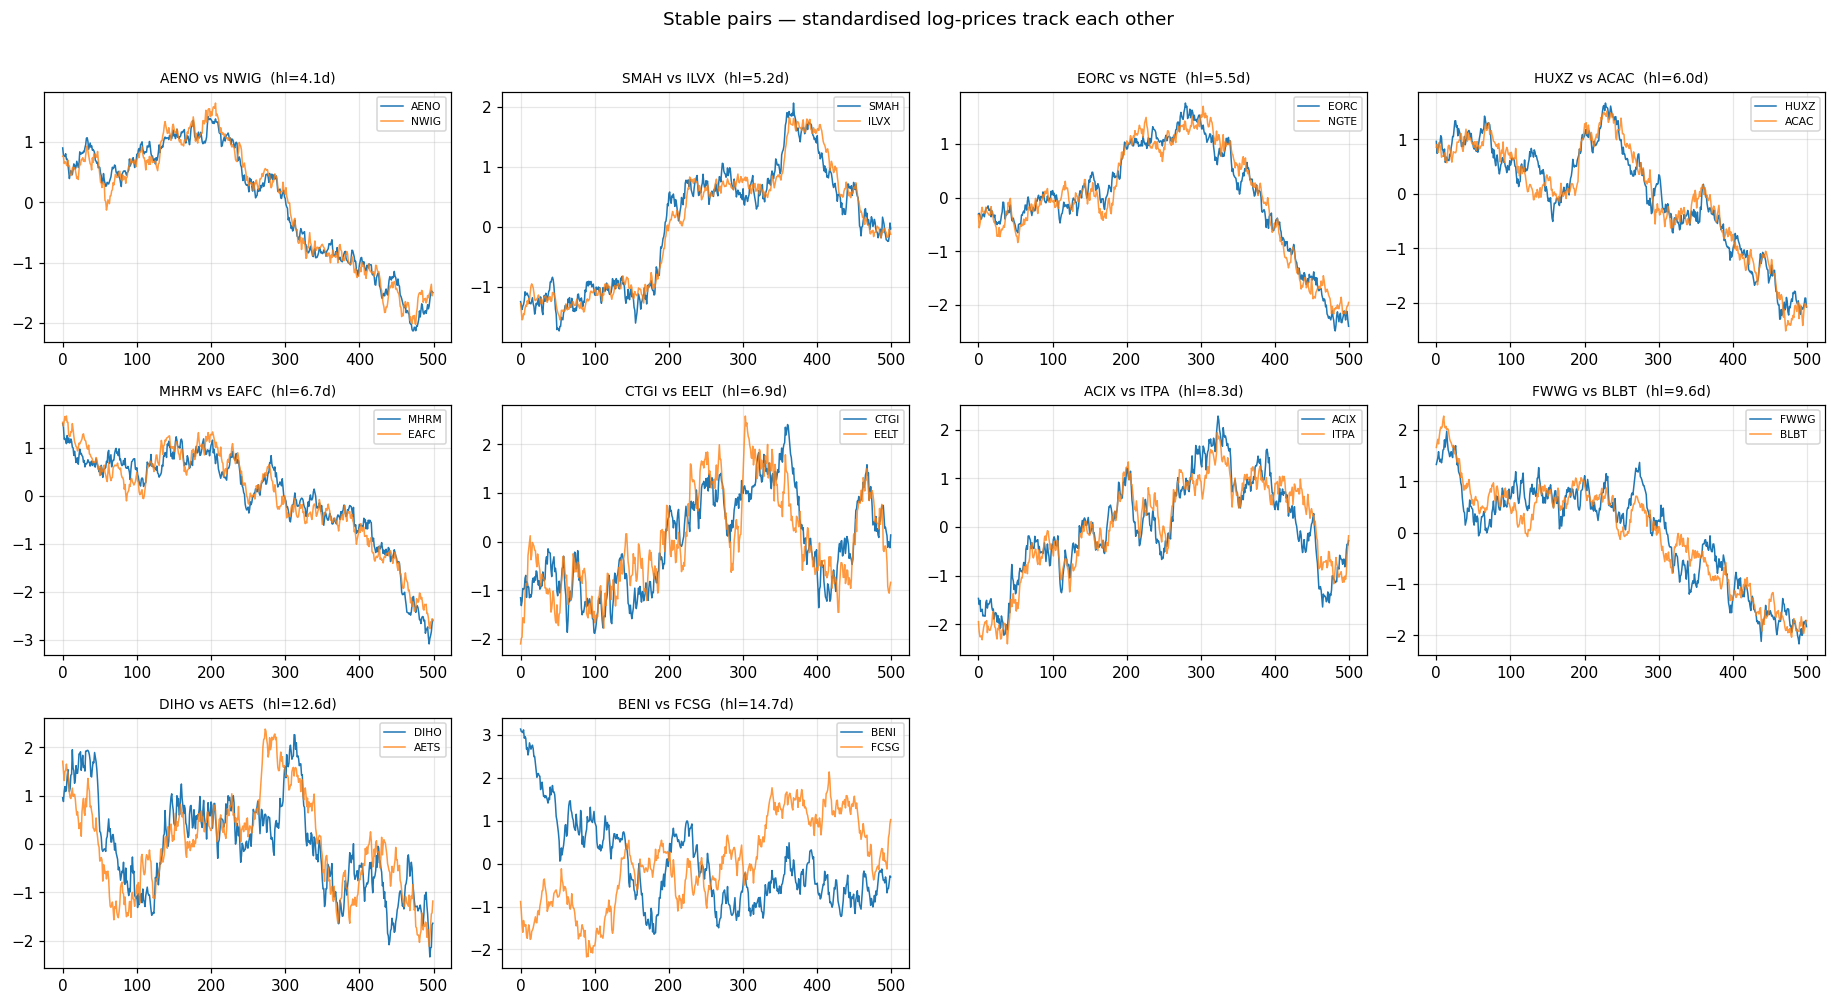

In [3]:
pairs = list(stable[["a","b","beta"]].itertuples(index=False,name=None))
k = len(pairs); ncol=4; nrow=int(np.ceil(k/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(4.2*ncol,3*nrow))
for idx,(a,b,beta) in enumerate(pairs):
    ax=axes.flat[idx]
    za=(logP[a]-logP[a].mean())/logP[a].std(); zb=(logP[b]-logP[b].mean())/logP[b].std()
    ax.plot(za,lw=1,label=a); ax.plot(zb,lw=1,alpha=0.8,label=b)
    ax.set_title(f"{a} vs {b}  (hl={stable.half_life[idx]:.1f}d)",fontsize=9); ax.legend(fontsize=7)
for j in range(k,nrow*ncol): axes.flat[j].axis("off")
fig.suptitle("Stable pairs — standardised log-prices track each other",y=1.01)
plt.tight_layout(); plt.show()

## 3. The tradeable object: spread z-scores
Crossing ±2σ then reverting to 0, in *both* halves (orange split), is the trade.

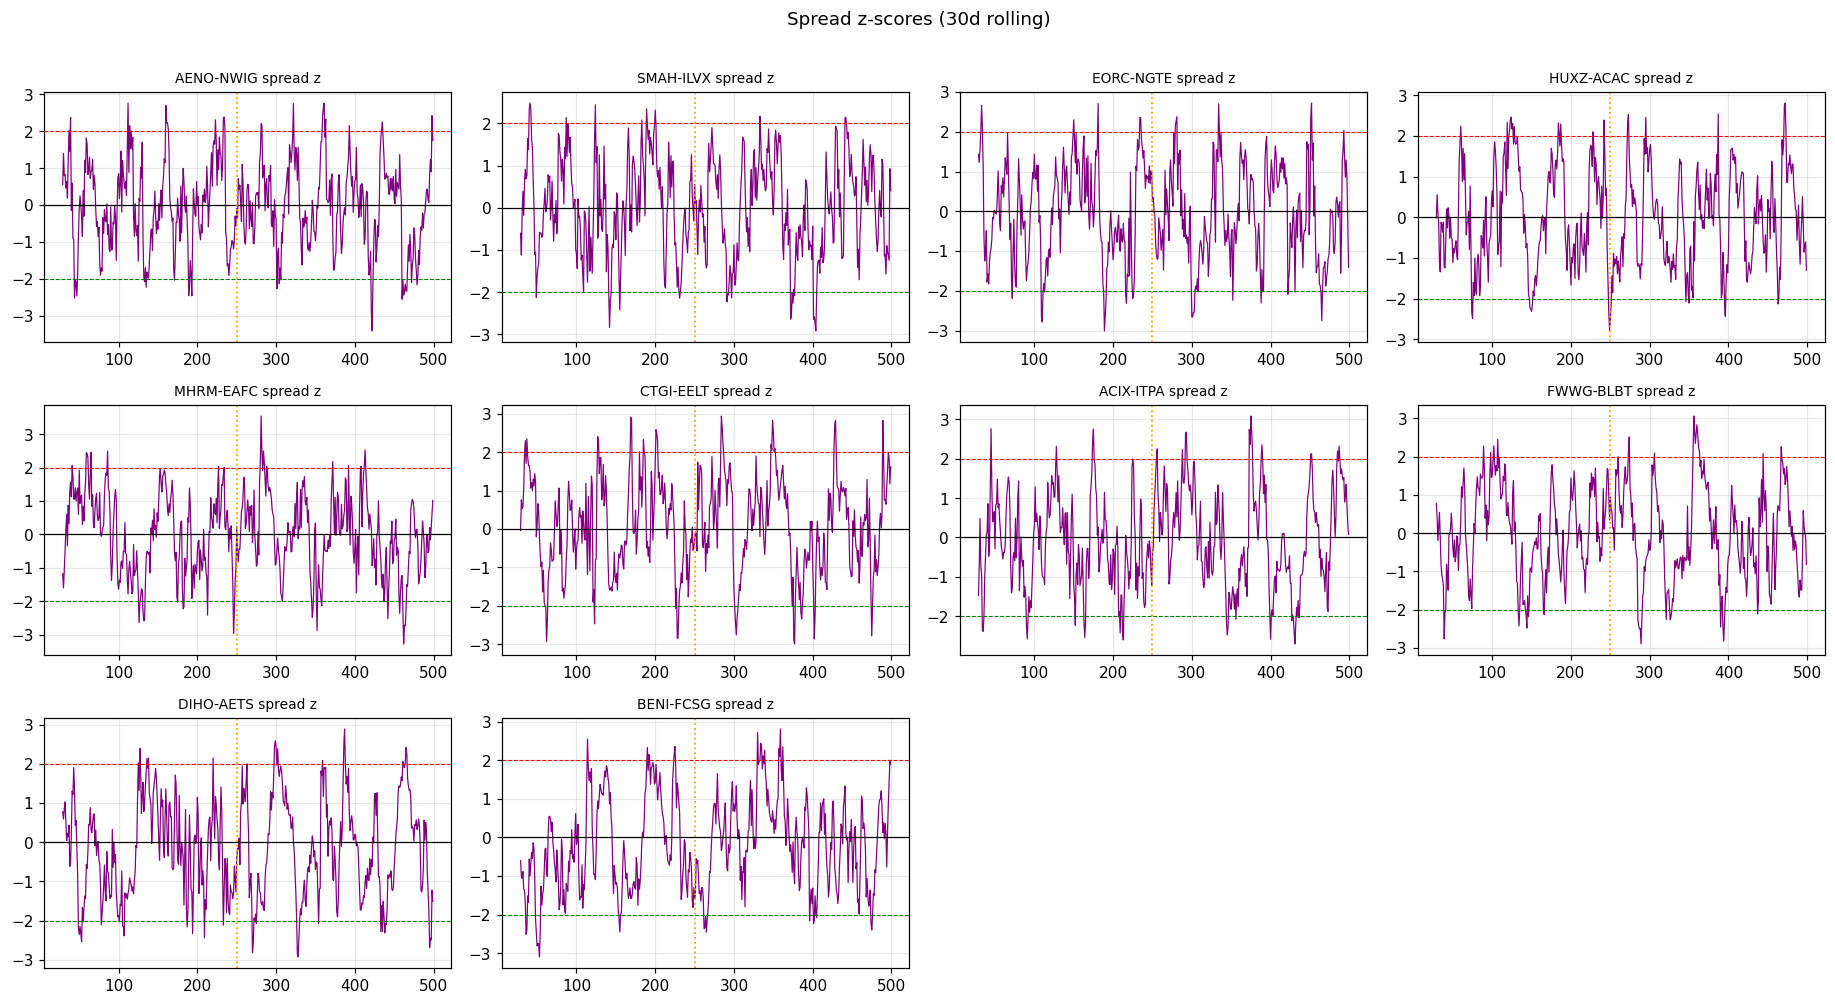

In [4]:
def zspread(a,b,beta,L=30):
    s=logP[a]-beta*logP[b]; return (s-s.rolling(L).mean())/s.rolling(L).std()

fig,axes=plt.subplots(nrow,ncol,figsize=(4.2*ncol,3*nrow))
for idx,(a,b,beta) in enumerate(pairs):
    ax=axes.flat[idx]; z=zspread(a,b,beta)
    ax.plot(z,color="purple",lw=0.8)
    ax.axhline(0,color="k",lw=.8); ax.axhline(2,color="r",ls="--",lw=.7); ax.axhline(-2,color="g",ls="--",lw=.7)
    ax.axvline(half,color="orange",ls=":",lw=1.2)
    ax.set_title(f"{a}-{b} spread z",fontsize=9)
for j in range(k,nrow*ncol): axes.flat[j].axis("off")
fig.suptitle("Spread z-scores (30d rolling)",y=1.01); plt.tight_layout(); plt.show()

## 4. Single-pair dashboard
`pair_dashboard(a, b, beta)` — overlay, spread, z with entry/exit signals, rolling half-life.

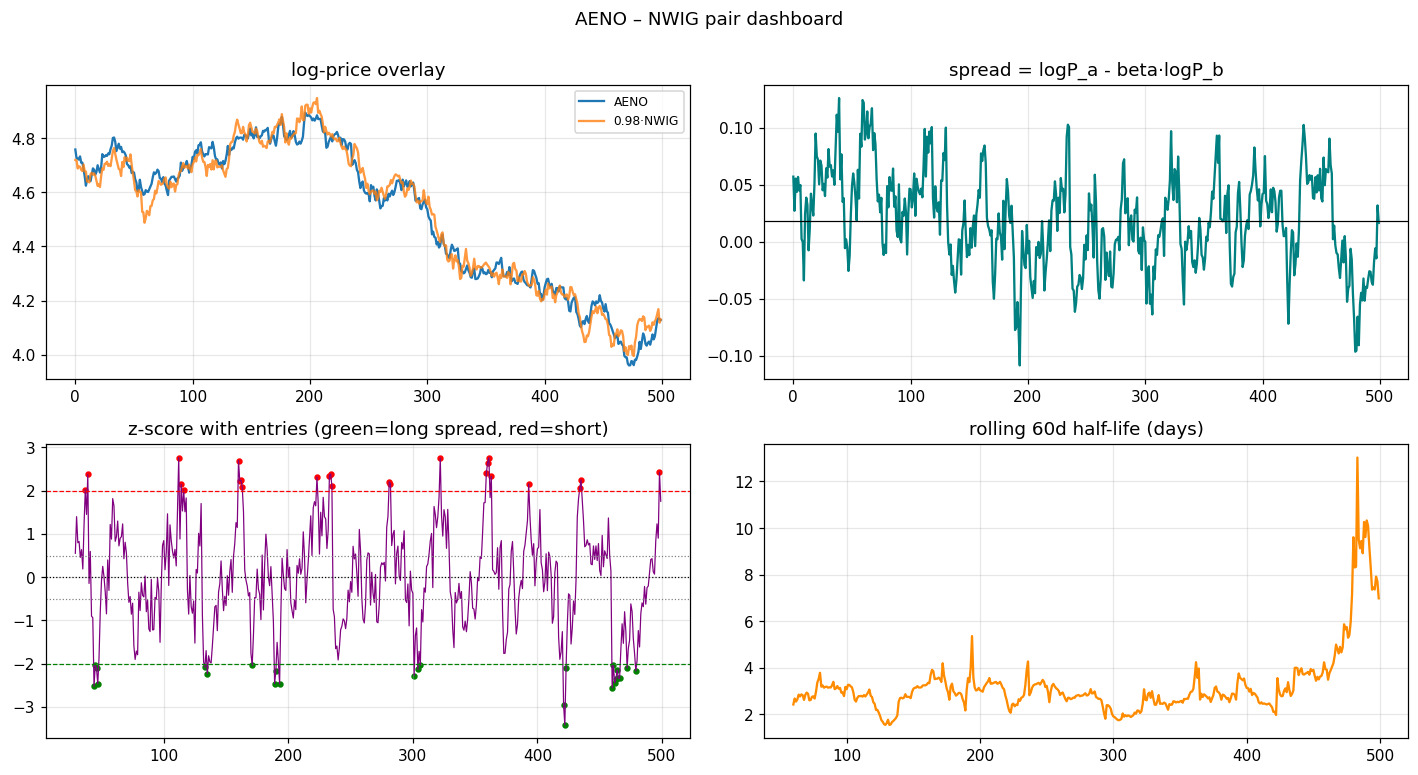

In [5]:
def pair_dashboard(a,b,beta=None,L=30,entry=2,exit=0.5):
    if beta is None: beta=np.polyfit(logP[b],logP[a],1)[0]
    spread=logP[a]-beta*logP[b]
    z=(spread-spread.rolling(L).mean())/spread.rolling(L).std()
    fig,ax=plt.subplots(2,2,figsize=(13,7))
    ax[0,0].plot(logP[a],label=a); ax[0,0].plot(beta*logP[b]+ (logP[a].mean()-beta*logP[b].mean()),label=f"{beta:.2f}·{b}",alpha=.8)
    ax[0,0].set_title("log-price overlay"); ax[0,0].legend(fontsize=8)
    ax[0,1].plot(spread,color="teal"); ax[0,1].axhline(spread.mean(),color="k",lw=.8)
    ax[0,1].set_title("spread = logP_a - beta·logP_b")
    ax[1,0].plot(z,color="purple",lw=.8); 
    for lvl,c in [(entry,"r"),(-entry,"g"),(exit,"0.5"),(-exit,"0.5"),(0,"k")]:
        ax[1,0].axhline(lvl,color=c,ls="--" if abs(lvl)==entry else ":",lw=.8)
    longs=z<-entry; shorts=z>entry
    ax[1,0].scatter(np.where(longs)[0],z[longs],c="g",s=10); ax[1,0].scatter(np.where(shorts)[0],z[shorts],c="r",s=10)
    ax[1,0].set_title(f"z-score with entries (green=long spread, red=short)")
    hl=[half_life(spread.values[max(0,i-60):i]) for i in range(60,len(spread))]
    ax[1,1].plot(range(60,len(spread)),np.clip(hl,0,40),color="darkorange")
    ax[1,1].set_title("rolling 60d half-life (days)")
    plt.suptitle(f"{a} – {b} pair dashboard",y=1.0); plt.tight_layout(); plt.show()

a0,b0,beta0=pairs[0]; pair_dashboard(a0,b0,beta0)

## 5. Are there GROUPS? (clustering on residual correlation)
Short branches = genuine co-movement beyond the market. Spoiler: the market is the only broad factor.

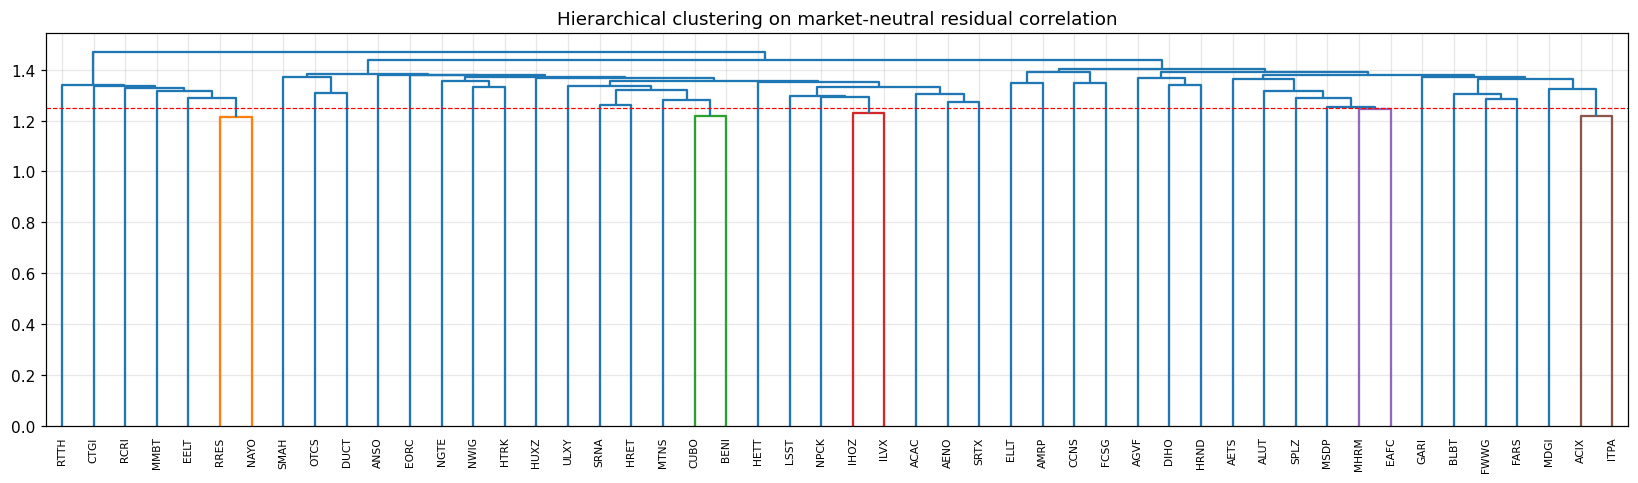

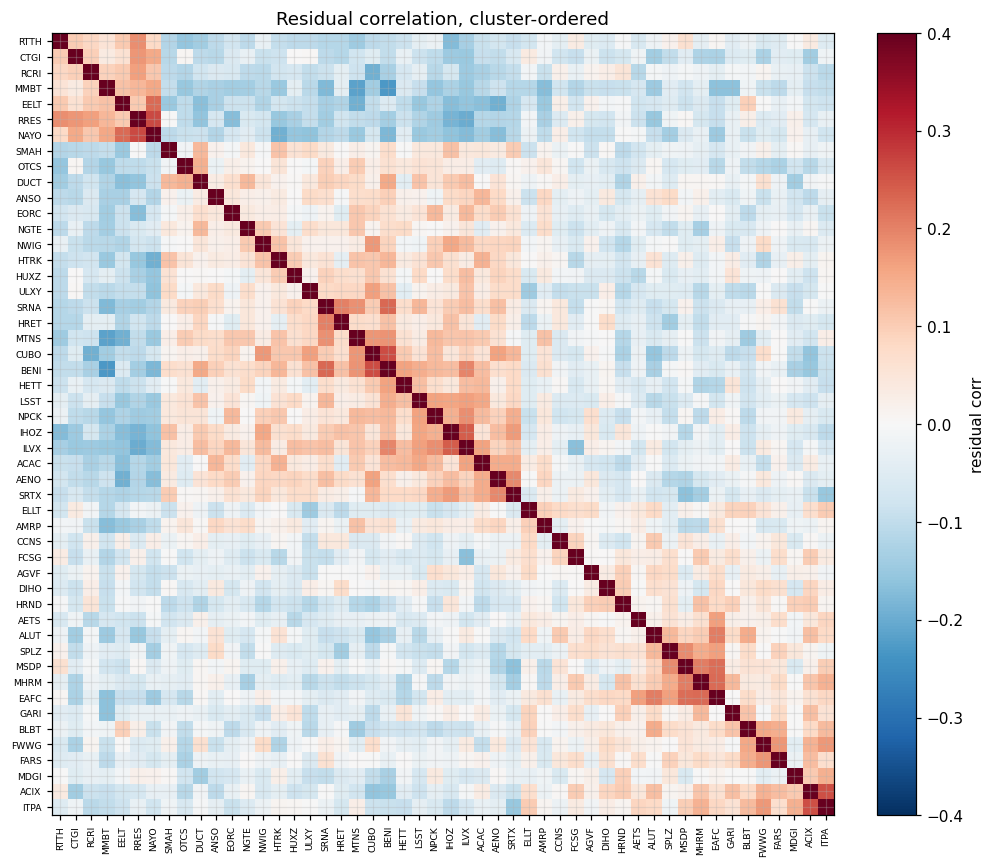

Groups with >1 member: [['CUBO', 'BENI'], ['RRES', 'NAYO'], ['ACIX', 'ITPA'], ['IHOZ', 'ILVX'], ['MHRM', 'EAFC']]


In [6]:
C=resid.corr()
D=np.sqrt(np.clip(2*(1-C.values),0,None)); np.fill_diagonal(D,0)
Z=linkage(squareform(D,checks=False),method="average")
fig,ax=plt.subplots(figsize=(15,4.5))
dendrogram(Z,labels=names,leaf_font_size=7,ax=ax,color_threshold=1.25); ax.axhline(1.25,color="r",ls="--",lw=.8)
ax.set_title("Hierarchical clustering on market-neutral residual correlation"); plt.tight_layout(); plt.show()

order=leaves_list(Z)
fig,ax=plt.subplots(figsize=(9,8))
im=ax.imshow(C.values[np.ix_(order,order)],cmap="RdBu_r",vmin=-.4,vmax=.4)
ax.set_xticks(range(len(names))); ax.set_xticklabels(np.array(names)[order],rotation=90,fontsize=6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(np.array(names)[order],fontsize=6)
plt.colorbar(im,fraction=0.046,label="residual corr"); ax.set_title("Residual correlation, cluster-ordered")
plt.tight_layout(); plt.show()

cl=fcluster(Z,1.25,criterion="distance"); g={}
for t,c in zip(names,cl): g.setdefault(c,[]).append(t)
print("Groups with >1 member:", [v for v in g.values() if len(v)>1])

## 6. Per-ticker character: mean-revert vs trend (Hurst)
Hurst of the idiosyncratic path. H<0.45 reverts, H>0.55 trends, else random walk.

character
random         25
mean-revert    19
trend           6


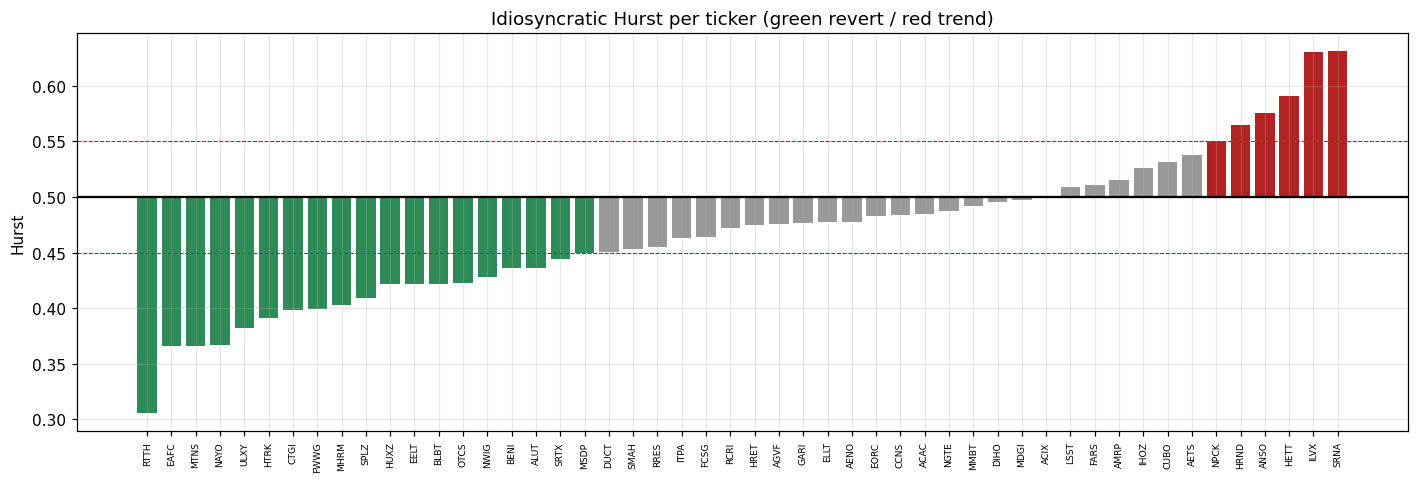

Trenders: ['NPCK', 'HRND', 'ANSO', 'HETT', 'ILVX', 'SRNA']


,hurst,resid_ac1,character
RTTH,0.306,0.041,mean-revert
EAFC,0.366,-0.008,mean-revert
MTNS,0.366,-0.022,mean-revert
NAYO,0.367,-0.007,mean-revert
ULXY,0.382,-0.012,mean-revert
HTRK,0.391,-0.093,mean-revert
CTGI,0.398,0.039,mean-revert
FWWG,0.400,0.021,mean-revert
MHRM,0.403,-0.072,mean-revert
SPLZ,0.409,-0.031,mean-revert


In [7]:
def hurst(ts,maxlag=40):
    lags=range(2,maxlag); tau=[np.sqrt(np.std(ts[l:]-ts[:-l])) for l in lags]
    return np.polyfit(np.log(lags),np.log(tau),1)[0]*2.0

char=pd.DataFrame({
    "hurst":[hurst(np.cumsum(resid[t].values)) for t in names],
    "resid_ac1":[pd.Series(resid[t]).autocorr(1) for t in names],
},index=names)
char["character"]=np.where(char.hurst<0.45,"mean-revert",np.where(char.hurst>0.55,"trend","random"))
char=char.sort_values("hurst")
print(char.character.value_counts().to_string()); 

col=np.where(char.hurst<0.45,"seagreen",np.where(char.hurst>0.55,"firebrick","0.6"))
fig,ax=plt.subplots(figsize=(13,4.5))
ax.bar(range(len(char)),char.hurst-0.5,bottom=0.5,color=col)
ax.axhline(0.5,color="k"); ax.axhline(0.45,color="green",ls="--",lw=.7); ax.axhline(0.55,color="red",ls="--",lw=.7)
ax.set_xticks(range(len(char))); ax.set_xticklabels(char.index,rotation=90,fontsize=6); ax.set_ylabel("Hurst")
ax.set_title("Idiosyncratic Hurst per ticker (green revert / red trend)"); plt.tight_layout(); plt.show()
print("Trenders:", list(char[char.character=='trend'].index))
char.round(3)

## 7. Pairs backtest with both-halves robustness
Faithful mini-simulator (per-instrument $10k cap, 1bp commission — mirrors `eval.py`).
The point is the **equity curves**: full period plus each half, to confirm the edge is not
carried by one regime (the failure mode of the earlier submission).

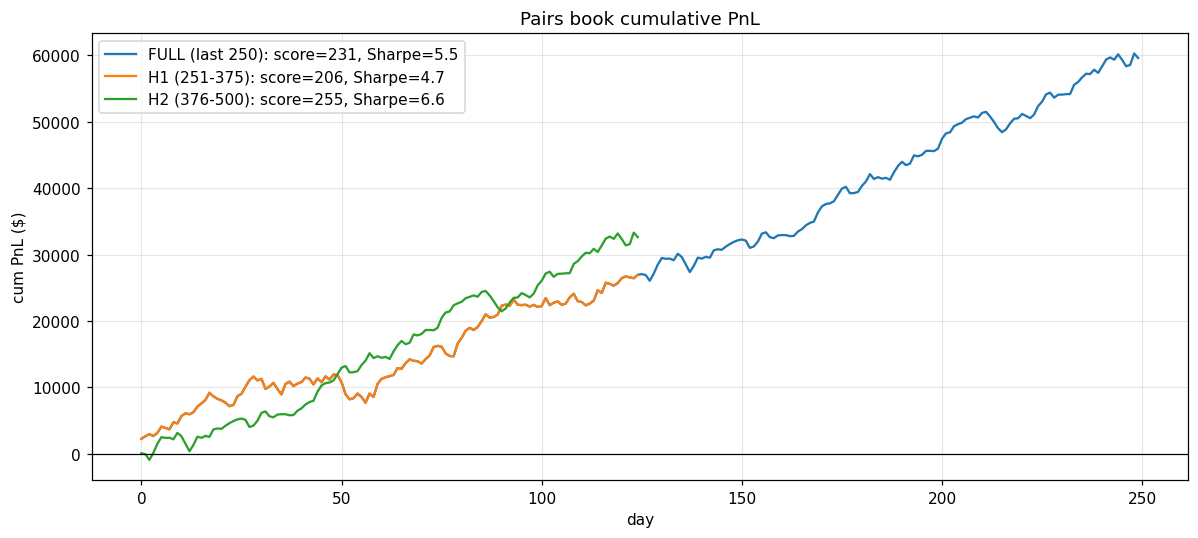

In [8]:
COMM=0.0001; CAP=10000
def run(get_pos, P, ndays):
    n,nt=P.shape; cash=0; cur=np.zeros(n); val=0; comm=0; pnl=[]
    for t in range(nt-ndays, nt+1):
        px=P[:,t-1] if t<=nt else P[:,-1]
        px=P[:,min(t,nt)-1]
        if t<nt:
            tgt=get_pos(P[:,:t]); lim=(CAP/px).astype(int); new=np.clip(tgt,-lim,lim).astype(int)
        else: new=cur
        d=new-cur; cash-=px.dot(d)+comm; comm=np.sum(px*np.abs(d))*COMM
        cur=new; v=cash+cur.dot(px); pnl.append(v-val); val=v
    pnl=np.array(pnl[1:]); mu=pnl.mean(); sd=pnl.std()
    sr=np.sqrt(250)*mu/sd if sd>0 else 0
    score=mu if mu<=0 else mu*sr**2/(sr**2+1)
    return pnl, dict(mu=mu,sharpe=sr,score=score)

idx={t:i for i,t in enumerate(tickers)}
PAIR_IDX=[(idx[a],idx[b],beta) for a,b,beta in pairs]
def pairs_positions(prcSoFar, L=30, dollar=9000):
    n,t=prcSoFar.shape; pos=np.zeros(n)
    if t<L+5: return pos
    lp=np.log(prcSoFar)
    for ia,ib,beta in PAIR_IDX:
        s=lp[ia]-beta*lp[ib]; z=(s[-1]-s[-L:].mean())/(s[-L:].std()+1e-9)
        w=-np.clip(z,-3,3)
        pos[ia]+=dollar*w/prcSoFar[ia,-1]; pos[ib]+=-dollar*w/prcSoFar[ib,-1]
    return pos

P=df.values.T
fig,ax=plt.subplots(figsize=(11,5))
for label,(sl,nd) in {"FULL (last 250)":(P,250),"H1 (251-375)":(P[:,:375],125),"H2 (376-500)":(P[:,:500],125)}.items():
    pnl,st=run(lambda ps: pairs_positions(ps), sl, nd)
    ax.plot(np.cumsum(pnl),label=f"{label}: score={st['score']:.0f}, Sharpe={st['sharpe']:.1f}")
ax.axhline(0,color="k",lw=.8); ax.set_title("Pairs book cumulative PnL"); ax.set_xlabel("day"); ax.set_ylabel("cum PnL ($)"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Interactive pair explorer (optional — needs `ipywidgets`)

In [9]:
try:
    from ipywidgets import interact, Dropdown
    labels={f"{a}-{b}":(a,b,beta) for a,b,beta in pairs}
    interact(lambda pair: pair_dashboard(*labels[pair]),
             pair=Dropdown(options=list(labels), description="pair"))
except ImportError:
    print("ipywidgets not installed — call pair_dashboard('AENO','NWIG') manually.")

interactive(children=(Dropdown(description='pair', options=('AENO-NWIG', 'SMAH-ILVX', 'EORC-NGTE', 'HUXZ-ACAC'…